##***Strategi Berbasis Data untuk Status Gizi: Analisis Double Burden melalui 5 Indikator Utama***

---

Dataset yang digunakan mencakup data prevalensi status gizi balita pada 38 provinsi di Indonesia dalam bentuk data numerik. Data tersebut digunakan untuk menganalisis kondisi status gizi balita serta mengidentifikasi pola persebaran permasalahan gizi di setiap wilayah Provinsi.
Adapun indikator status gizi yang digunakan dalam penelitian ini meliputi:
Stunting (Tinggi Badan menurut Umur).
Underweight (Berat Badan menurut Umur).
Wasting (Berat Badan menurut Tinggi Badan - Kurang Gizi).
Severe Wasting (Berat Badan menurut Tinggi Badan - Gizi Buruk).
Overweight (Berat Badan menurut Tinggi Badan - Gizi Lebih).



In [ ]:
# =========================================================================
# TAHAP LOAD DATA & SELEKSI FITUR UTAMA
# =========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------------------------
nama_file = 'data gizi indonesia.xlsx'

# Membaca data
df_raw = pd.read_excel(nama_file, skiprows=2)

# Menyeragamkan nama kolom pertama
df_raw.rename(columns={df_raw.columns[0]: 'Provinsi'}, inplace=True)

# Membersihkan nama kolom
df_raw.columns = df_raw.columns.str.strip()

# Membersihkan nama provinsi
df_raw['Provinsi'] = (
    df_raw['Provinsi']
    .astype(str)
    .str.strip()
)

# Hapus baris kosong
df_raw = df_raw[df_raw['Provinsi'].notna()]

# Hapus baris footer jika ada
df_raw = df_raw[
    ~df_raw['Provinsi'].str.contains(
        'sumber|keterangan|total',
        case=False,
        na=False
    )
]

print("=== DAFTAR KOLOM DATA ===")
for i, col in enumerate(df_raw.columns):
    print(f"{i} : {col}")

# -------------------------------------------------------------------------
# PEMILIHAN FITUR STATUS GIZI
# -------------------------------------------------------------------------

df_select = df_raw.iloc[:, [0,1,3,5,7,9]].copy()

df_select.columns = [
    'Provinsi',
    'Stunting',
    'Underweight',
    'Severe Wasting',
    'Wasting',
    'Overweight'
]

# -------------------------------------------------------------------------
# KONVERSI KE NUMERIK
# -------------------------------------------------------------------------

features = [
    'Stunting',
    'Underweight',
    'Severe Wasting',
    'Wasting',
    'Overweight'
]

for col in features:

    df_select[col] = (
        df_select[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
    )

    df_select[col] = pd.to_numeric(
        df_select[col],
        errors='coerce'
    )

# -------------------------------------------------------------------------
# PERBAIKAN DATA PAPUA DARI PDF SSGI
# -------------------------------------------------------------------------

df_select.loc[
    df_select['Provinsi'].str.contains('Papua Selatan', case=False, na=False),
    'Wasting'
] = 10.9

df_select.loc[
    df_select['Provinsi'].str.contains('Papua Tengah', case=False, na=False),
    'Wasting'
] = 12.0

df_select.loc[
    df_select['Provinsi'].str.contains('Papua Pegunungan', case=False, na=False),
    'Wasting'
] = 8.4

# -------------------------------------------------------------------------
# CEK MISSING VALUE
# -------------------------------------------------------------------------

print("\n=== MISSING VALUE SEBELUM IMPUTASI ===")
print(df_select[features].isnull().sum())

# -------------------------------------------------------------------------
# IMPUTASI SEVERE WASTING
# -------------------------------------------------------------------------

median_sw = df_select['Severe Wasting'].median()

print(f"\nMedian Severe Wasting = {median_sw:.2f}")

df_select['Severe Wasting'] = (
    df_select['Severe Wasting']
    .fillna(median_sw)
)

print("\n=== DATA PAPUA HASIL PERBAIKAN ===")

display(
    df_select[
        df_select['Provinsi'].isin([
            'Papua Selatan',
            'Papua Tengah',
            'Papua Pegunungan'
        ])
    ]
)

# -------------------------------------------------------------------------
# CEK AKHIR
# -------------------------------------------------------------------------

print("\n=== MISSING VALUE SETELAH IMPUTASI ===")
print(df_select[features].isnull().sum())


# -------------------------------------------------------------------------
# MEMBUAT DATAFRAME FINAL
# -------------------------------------------------------------------------

df = df_select.copy()

df.reset_index(drop=True, inplace=True)

# -------------------------------------------------------------------------
# VALIDASI DATA
# -------------------------------------------------------------------------

print("\n=== INFORMASI DATA ===")
print(f"Jumlah Provinsi : {df['Provinsi'].nunique()}")
print(f"Jumlah Baris    : {df.shape[0]}")
print(f"Jumlah Kolom    : {df.shape[1]}")

print("\n=== CEK MISSING VALUE ===")
print(df[features].isnull().sum())

# -------------------------------------------------------------------------
# CEK PAPUA PEGUNUNGAN
# -------------------------------------------------------------------------

print("\n=== CEK PAPUA PEGUNUNGAN ===")

papua_pegunungan = df[
    df['Provinsi']
    .str.contains('Papua Pegunungan', case=False, na=False)
]

display(papua_pegunungan)

# -------------------------------------------------------------------------
# STATISTIK DESKRIPTIF
# -------------------------------------------------------------------------

print("\n=== STATISTIK DESKRIPTIF ===")
display(df[features].describe().round(2))

# -------------------------------------------------------------------------
# SELURUH PROVINSI
# -------------------------------------------------------------------------

print("\n=== DAFTAR PROVINSI ===")
display(df[['Provinsi']])

print("\n=== 5 DATA TERAKHIR ===")
display(df.tail())

=== DAFTAR KOLOM DATA ===
0 : Provinsi
1 : %
2 : 95% CI
3 : %_1
4 : 95% CI_2
5 : %_3
6 : 95% CI_4
7 : %_5
8 : 95% CI_6
9 : %_7
10 : 95% CI_8

=== MISSING VALUE SEBELUM IMPUTASI ===
Stunting          0
Underweight       0
Severe Wasting    3
Wasting           0
Overweight        0
dtype: int64

Median Severe Wasting = 1.60

=== DATA PAPUA HASIL PERBAIKAN ===


,Provinsi,Stunting,Underweight,Severe Wasting,Wasting,Overweight
35,Papua Selatan,25.8,20.5,1.6,10.9,3.8
36,Papua Tengah,32.5,26.5,1.6,12.0,5.6
37,Papua Pegunungan,40.0,22.3,1.6,8.4,10.3



=== MISSING VALUE SETELAH IMPUTASI ===
Stunting          0
Underweight       0
Severe Wasting    0
Wasting           0
Overweight        0
dtype: int64

=== INFORMASI DATA ===
Jumlah Provinsi : 38
Jumlah Baris    : 38
Jumlah Kolom    : 6

=== CEK MISSING VALUE ===
Stunting          0
Underweight       0
Severe Wasting    0
Wasting           0
Overweight        0
dtype: int64

=== CEK PAPUA PEGUNUNGAN ===


,Provinsi,Stunting,Underweight,Severe Wasting,Wasting,Overweight
37,Papua Pegunungan,40.0,22.3,1.6,8.4,10.3



=== STATISTIK DESKRIPTIF ===


,Stunting,Underweight,Severe Wasting,Wasting,Overweight
count,38.00,38.00,38.00,38.00,38.00
mean,23.01,19.71,1.73,7.61,3.64
std,6.66,5.71,0.89,2.22,1.73
min,8.70,7.20,0.30,3.10,1.40
25%,17.45,14.92,1.00,5.90,2.52
50%,22.55,19.10,1.60,7.40,3.25
75%,26.10,23.75,2.20,9.05,4.47
max,40.00,34.40,3.70,12.30,10.30



=== DAFTAR PROVINSI ===


,Provinsi
0,Aceh
1,Sumatera Utara
2,Sumatera Barat
3,Riau
4,Jambi
5,Sumatera Selatan
6,Bengkulu
7,Lampung
8,Bangka Belitung
9,Kepulauan Riau



=== 5 DATA TERAKHIR ===


,Provinsi,Stunting,Underweight,Severe Wasting,Wasting,Overweight
33,Papua Barat Daya,30.5,28.8,3.7,9.4,1.9
34,Papua,24.7,19.1,2.7,7.9,3.5
35,Papua Selatan,25.8,20.5,1.6,10.9,3.8
36,Papua Tengah,32.5,26.5,1.6,12.0,5.6
37,Papua Pegunungan,40.0,22.3,1.6,8.4,10.3


In [ ]:
# =========================================================================
# TAHAP  DETEKSI OUTLIER (IQR) & MIN-MAX SCALING
# =========================================================================

from sklearn.preprocessing import MinMaxScaler

# -------------------------------------------------------------------------
# DETEKSI OUTLIER MENGGUNAKAN IQR
# -------------------------------------------------------------------------

Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outlier_mask = (
    ((df[features] < lower_bound) |
     (df[features] > upper_bound))
    .any(axis=1)
)

outlier_data = df[outlier_mask]

print("=== DETEKSI OUTLIER ===")
print(f"Jumlah provinsi terindikasi outlier : {len(outlier_data)}")

if len(outlier_data) > 0:
    display(outlier_data[['Provinsi'] + features])

print("\nSeluruh 38 provinsi tetap digunakan dalam analisis.")
print("Outlier tidak dihapus karena merupakan kondisi nyata wilayah.")

# -------------------------------------------------------------------------
# VALIDASI DATA
# -------------------------------------------------------------------------

print("\n=== CEK MISSING VALUE ===")
print(df[features].isnull().sum())

# -------------------------------------------------------------------------
# MIN-MAX SCALING
# -------------------------------------------------------------------------

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(
    df[features]
)

df_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

print("\nShape X_scaled :", X_scaled.shape)
print("Jumlah NaN setelah scaling :", np.isnan(X_scaled).sum())

print("\n=== HASIL MIN-MAX SCALING ===")
display(df_scaled.head())

=== DETEKSI OUTLIER ===
Jumlah provinsi terindikasi outlier : 1


,Provinsi,Stunting,Underweight,Severe Wasting,Wasting,Overweight
37,Papua Pegunungan,40.0,22.3,1.6,8.4,10.3



Seluruh 38 provinsi tetap digunakan dalam analisis.
Outlier tidak dihapus karena merupakan kondisi nyata wilayah.

=== CEK MISSING VALUE ===
Stunting          0
Underweight       0
Severe Wasting    0
Wasting           0
Overweight        0
dtype: int64

Shape X_scaled : (38, 5)
Jumlah NaN setelah scaling : 0

=== HASIL MIN-MAX SCALING ===


,Stunting,Underweight,Severe Wasting,Wasting,Overweight
0,0.635783,0.610294,0.382353,0.532609,0.067416
1,0.424920,0.382353,0.529412,0.413043,0.101124
2,0.517572,0.426471,0.176471,0.326087,0.033708
3,0.364217,0.474265,0.529412,0.608696,0.134831
4,0.268371,0.242647,0.588235,0.347826,0.359551


=== EVALUASI JUMLAH KLASTER OPTIMAL ===
Shape X_scaled : (38, 5)
Jumlah NaN : 0

=== HASIL EVALUASI ===


,k,WSS,Silhouette Score
0,2,4.8016,0.4069
1,3,3.6350,0.3786
2,4,2.8013,0.3846
3,5,2.3575,0.2801
4,6,1.9705,0.2918
5,7,1.7145,0.2830
6,8,1.3958,0.2984
7,9,1.1238,0.3198
8,10,0.9990,0.2930



Jumlah klaster terbaik berdasarkan Silhouette = 2
Nilai Silhouette tertinggi = 0.4069


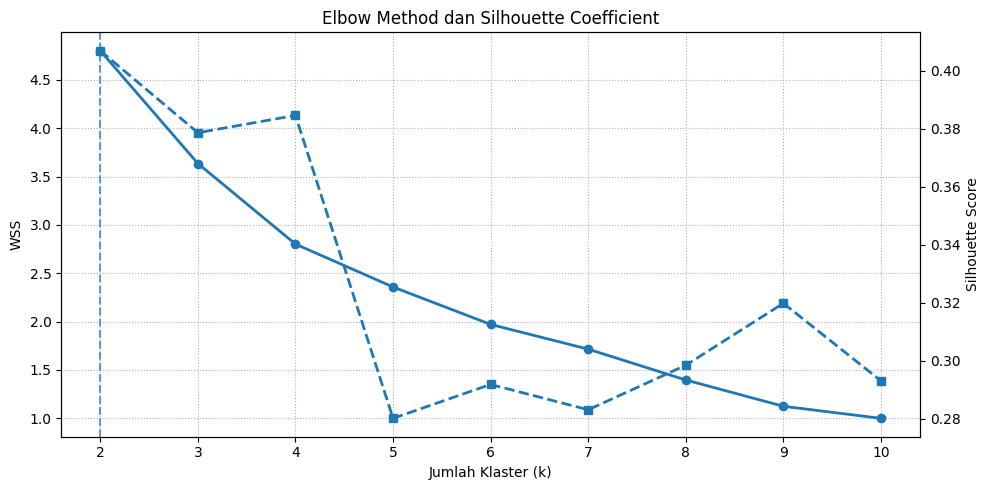

In [ ]:
# =========================================================================
# TAHAP ELBOW METHOD & SILHOUETTE COEFFICIENT
# =========================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("=== EVALUASI JUMLAH KLASTER OPTIMAL ===")

# -------------------------------------------------------------------------
# VALIDASI DATA
# -------------------------------------------------------------------------

print("Shape X_scaled :", X_scaled.shape)
print("Jumlah NaN :", np.isnan(X_scaled).sum())

# -------------------------------------------------------------------------
# ELBOW & SILHOUETTE
# -------------------------------------------------------------------------

wss = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    wss.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

# -------------------------------------------------------------------------
# TABEL HASIL EVALUASI
# -------------------------------------------------------------------------

hasil_evaluasi = pd.DataFrame({
    'k': list(k_values),
    'WSS': wss,
    'Silhouette Score': silhouette_scores
})

print("\n=== HASIL EVALUASI ===")
display(hasil_evaluasi.round(4))

# -------------------------------------------------------------------------
# MENENTUKAN KLASTER TERBAIK
# -------------------------------------------------------------------------

best_idx = np.argmax(silhouette_scores)

best_k = list(k_values)[best_idx]
best_score = silhouette_scores[best_idx]

print(f"\nJumlah klaster terbaik berdasarkan Silhouette = {best_k}")
print(f"Nilai Silhouette tertinggi = {best_score:.4f}")

# -------------------------------------------------------------------------
# VISUALISASI
# -------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(10,5))

# Elbow Method
ax1.plot(
    k_values,
    wss,
    marker='o',
    linewidth=2,
    label='WSS'
)

ax1.set_xlabel('Jumlah Klaster (k)')
ax1.set_ylabel('WSS')
ax1.grid(True, linestyle=':')

# Garis k terbaik
ax1.axvline(
    best_k,
    linestyle='--',
    alpha=0.7
)

# Silhouette
ax2 = ax1.twinx()

ax2.plot(
    k_values,
    silhouette_scores,
    marker='s',
    linestyle='--',
    linewidth=2
)

ax2.set_ylabel('Silhouette Score')

plt.title(
    'Elbow Method dan Silhouette Coefficient'
)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# EKSEKUSI K-MEANS CLUSTERING FINAL (FIXED & CLEAN)
# =========================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

optimal_k = 3

# =========================
# SAFETY CHECK
# =========================
assert 'X_scaled' in globals(), "X_scaled belum dibuat"
assert 'features' in globals(), "features belum didefinisikan"
assert 'scaler' in globals(), "scaler belum dibuat"

# =========================
# 1. MODEL K-MEANS
# =========================
kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

print(f"[SUKSES] {len(df)} provinsi dibagi menjadi {optimal_k} cluster")

# =========================
# 2. SILHOUETTE SCORE
# =========================
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"\nSilhouette Score (k={optimal_k}) = {sil_score:.4f}")

# =========================
# 3. JUMLAH ANGGOTA CLUSTER
# =========================
print("\n=== JUMLAH PROVINSI PER KLUSTER ===")
print(df['Cluster'].value_counts().sort_index())

# =========================
# 4. CENTROID (SCALED)
# =========================
print("\n=== CENTROID (SCALED) ===")

centroids_scaled = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=features
)

print(centroids_scaled.round(3))

# =========================
# 5. CENTROID (ASLI)
# =========================
print("\n=== CENTROID (ASLI %) ===")

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_model.cluster_centers_),
    columns=features
)

print(centroids_original.round(2))

# =========================
# 6. PROFIL KLASTER
# =========================
print("\n=== KARAKTERISTIK KLASTER ===")

cluster_profile = df.groupby('Cluster')[features].mean().round(2)
print(cluster_profile)

# =========================
# 7. DAFTAR PROVINSI PER KLASTER
# =========================
print("\n=== DAFTAR PROVINSI PER KLASTER ===")

for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCLUSTER {cluster}")
    print("-" * 40)

    provinsi_cluster = df[df['Cluster'] == cluster]['Provinsi'].sort_values()

    print(", ".join(provinsi_cluster.tolist()))


[SUKSES] 38 provinsi dibagi menjadi 3 cluster

Silhouette Score (k=3) = 0.3786

=== JUMLAH PROVINSI PER KLUSTER ===
Cluster
0     4
1    18
2    16
Name: count, dtype: int64

=== CENTROID (SCALED) ===
   Stunting  Underweight  Severe Wasting  Wasting  Overweight
0     0.673        0.801           0.949    0.878       0.045
1     0.297        0.287           0.237    0.285       0.300
2     0.583        0.569           0.498    0.624       0.249

=== CENTROID (ASLI %) ===
   Stunting  Underweight  Severe Wasting  Wasting  Overweight
0     29.78        29.00            3.52    11.18        1.80
1     17.98        15.01            1.11     5.72        4.07
2     26.96        22.68            1.99     8.84        3.61

=== KARAKTERISTIK KLASTER ===
         Stunting  Underweight  Severe Wasting  Wasting  Overweight
Cluster                                                            
0           29.78        29.00            3.53    11.18        1.80
1           17.98        15.01           

In [ ]:
# =========================================================================
# TAHAP ANALISIS DESKRIPTIF NILAI EKSTREM
# =========================================================================

print("=== DAFTAR PROVINSI DENGAN PREVALENSI EKSTREM ===\n")

for col in features:

    idx_max = df[col].idxmax()
    idx_min = df[col].idxmin()

    print(f"Indikator : {col}")
    print(
        f"  Prevalensi Tertinggi : "
        f"{df.loc[idx_max, 'Provinsi']} "
        f"({df.loc[idx_max, col]:.2f}%)"
    )

    print(
        f"  Prevalensi Terendah  : "
        f"{df.loc[idx_min, 'Provinsi']} "
        f"({df.loc[idx_min, col]:.2f}%)"
    )

    print("-" * 60)

# =========================================================================
# TABEL NILAI EKSTREM
# =========================================================================

hasil_ekstrem = []

for col in features:

    idx_max = df[col].idxmax()
    idx_min = df[col].idxmin()

    hasil_ekstrem.append([
        col,
        df.loc[idx_max, 'Provinsi'],
        df.loc[idx_max, col],
        df.loc[idx_min, 'Provinsi'],
        df.loc[idx_min, col]
    ])

tabel_ekstrem = pd.DataFrame(
    hasil_ekstrem,
    columns=[
        'Indikator',
        'Provinsi Tertinggi',
        'Nilai Tertinggi (%)',
        'Provinsi Terendah',
        'Nilai Terendah (%)'
    ]
)

display(tabel_ekstrem.round(2))

=== DAFTAR PROVINSI DENGAN PREVALENSI EKSTREM ===

Indikator : Stunting
  Prevalensi Tertinggi : Papua Pegunungan (40.00%)
  Prevalensi Terendah  : Bali (8.70%)
------------------------------------------------------------
Indikator : Underweight
  Prevalensi Tertinggi : Nusa Tenggara Timur (34.40%)
  Prevalensi Terendah  : Bali (7.20%)
------------------------------------------------------------
Indikator : Severe Wasting
  Prevalensi Tertinggi : Papua Barat Daya (3.70%)
  Prevalensi Terendah  : Bali (0.30%)
------------------------------------------------------------
Indikator : Wasting
  Prevalensi Tertinggi : Nusa Tenggara Timur (12.30%)
  Prevalensi Terendah  : Bali (3.10%)
------------------------------------------------------------
Indikator : Overweight
  Prevalensi Tertinggi : Papua Pegunungan (10.30%)
  Prevalensi Terendah  : Nusa Tenggara Barat (1.40%)
------------------------------------------------------------


,Indikator,Provinsi Tertinggi,Nilai Tertinggi (%),Provinsi Terendah,Nilai Terendah (%)
0,Stunting,Papua Pegunungan,40.0,Bali,8.7
1,Underweight,Nusa Tenggara Timur,34.4,Bali,7.2
2,Severe Wasting,Papua Barat Daya,3.7,Bali,0.3
3,Wasting,Nusa Tenggara Timur,12.3,Bali,3.1
4,Overweight,Papua Pegunungan,10.3,Nusa Tenggara Barat,1.4


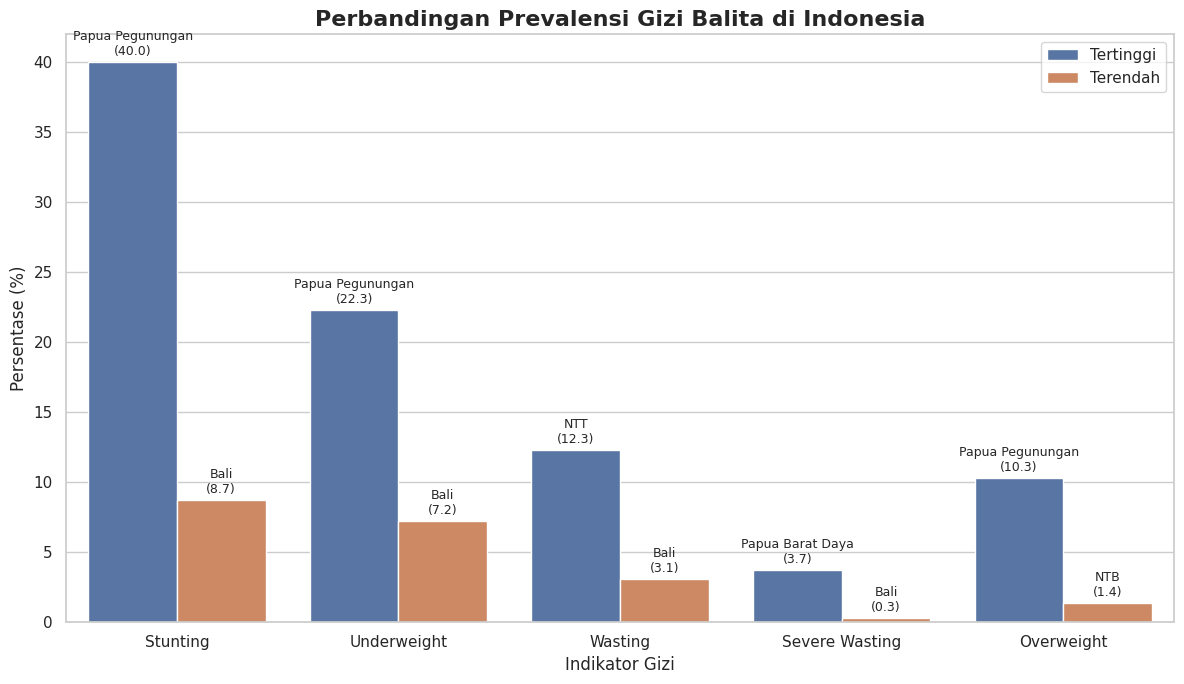

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  # bikin clean

data = {
    'Indikator': ['Stunting', 'Underweight', 'Wasting', 'Severe Wasting', 'Overweight'],
    'Tertinggi': [40.0, 22.3, 12.3, 3.7, 10.3],  # ⚠️ sudah aku perbaiki ya
    'Prov_Tinggi': ['Papua Pegunungan', 'Papua Pegunungan', 'NTT', 'Papua Barat Daya', 'Papua Pegunungan'],

    'Terendah': [8.7, 7.2, 3.1, 0.3, 1.4],
    'Prov_Rendah': ['Bali', 'Bali', 'Bali', 'Bali', 'NTB']
}

df = pd.DataFrame(data)

df_long = pd.melt(df,
                  id_vars=['Indikator'],
                  value_vars=['Tertinggi', 'Terendah'],
                  var_name='Kategori',
                  value_name='Nilai')

plt.figure(figsize=(12,7))

ax = sns.barplot(data=df_long, x='Indikator', y='Nilai', hue='Kategori')

plt.title('Perbandingan Prevalensi Gizi Balita di Indonesia', fontsize=16, weight='bold')
plt.xlabel('Indikator Gizi')
plt.ylabel('Persentase (%)')

# 🔥 Tambahin label provinsi + nilai
for i in range(len(df)):
    # Tertinggi
    plt.text(i - 0.2, df['Tertinggi'][i] + 0.5,
             f"{df['Prov_Tinggi'][i]}\n({df['Tertinggi'][i]})",
             ha='center', fontsize=9)

    # Terendah
    plt.text(i + 0.2, df['Terendah'][i] + 0.5,
             f"{df['Prov_Rendah'][i]}\n({df['Terendah'][i]})",
             ha='center', fontsize=9)

plt.legend(title='')
plt.tight_layout()
plt.show()

In [ ]:

# cek kolom
print(df_select.columns)

# hitung score
df_select['Double_Burden_Score'] = df_select['Stunting'] + df_select['Overweight']

# ranking
df_sorted = df_select.sort_values('Double_Burden_Score', ascending=False)

df_sorted.index = range(1, len(df_sorted)+1)
df_sorted.index.name = 'Ranking'

display(df_sorted[['Provinsi','Stunting','Overweight','Double_Burden_Score']])

Index(['Provinsi', 'Stunting', 'Underweight', 'Severe Wasting', 'Wasting',
       'Overweight', 'Double_Burden_Score'],
      dtype='object')


,Provinsi,Stunting,Overweight,Double_Burden_Score
Ranking,,,,
1,Papua Pegunungan,40.0,10.3,50.3
2,Nusa Tenggara Timur,37.0,1.6,38.6
3,Papua Tengah,32.5,5.6,38.1
4,Sulawesi Barat,35.4,2.2,37.6
5,Papua Barat Daya,30.5,1.9,32.4
6,Kalimantan Barat,26.8,4.4,31.2
7,Nusa Tenggara Barat,29.8,1.4,31.2
8,Aceh,28.6,2.0,30.6
9,Maluku,28.4,2.2,30.6


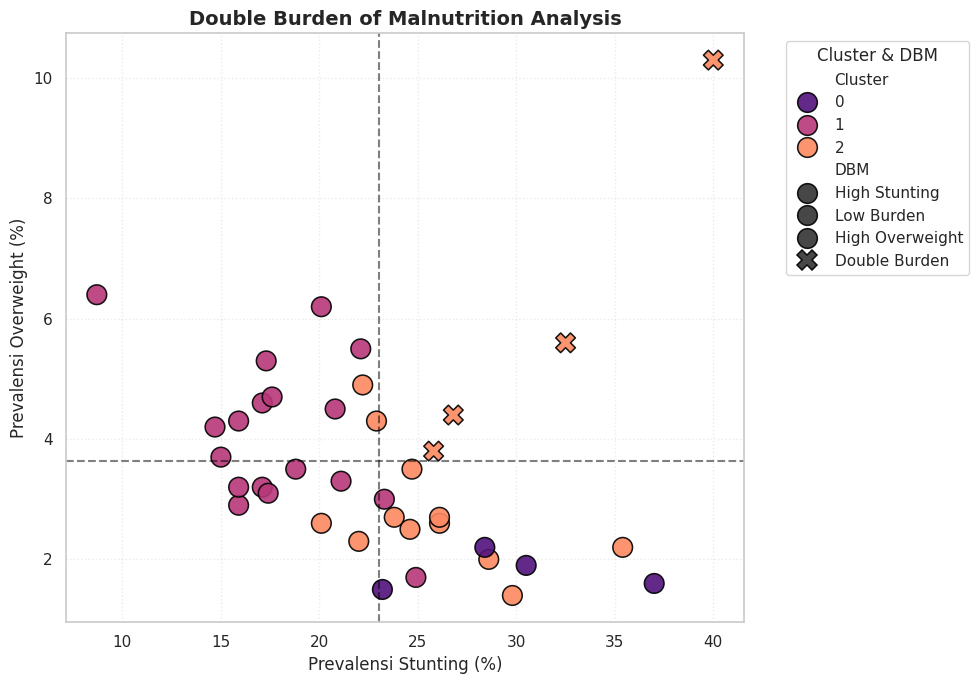

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Cluster' column is in df_select
# cluster_labels was created in cell 5OIorcG5UZsy
df_select['Cluster'] = cluster_labels

# 1. Pastikan kolom DBM sudah dibuat berdasarkan kondisi kuadran
# (Re-creating logic from deleted cell UDLtb28hRl2A)
mean_stunting = df_select['Stunting'].mean()
mean_overweight = df_select['Overweight'].mean()

def get_dbm_category(row):
    if row['Stunting'] > mean_stunting and row['Overweight'] > mean_overweight:
        return 'Double Burden'
    elif row['Stunting'] > mean_stunting:
        return 'High Stunting'
    elif row['Overweight'] > mean_overweight:
        return 'High Overweight'
    else:
        return 'Low Burden'

df_select['DBM'] = df_select.apply(get_dbm_category, axis=1)

# Pastikan jumlah warna sesuai dengan jumlah klaster (misal 3 klaster)
# Jika jumlah klaster Anda berbeda (misal 4), ubah n_colors menjadi 4
n_clusters = df_select['Cluster'].nunique()
my_palette = sns.color_palette("magma", n_colors=n_clusters)

# 2. Atur gaya marker:
# 'Double Burden' jadi silang ('X'), yang lain bulat ('o')
marker_shapes = {
    'Double Burden': 'X',
    'High Stunting': 'o',
    'High Overweight': 'o',
    'Low Burden': 'o'
}

plt.figure(figsize=(10, 7))

# 3. Plotting
sns.scatterplot(
    data=df_select, # Changed df to df_select
    x='Stunting',
    y='Overweight',
    hue='Cluster',          # Warna klaster dari palet magma
    style='DBM',            # Bentuk simbol dari marker_shapes
    markers=marker_shapes,
    s=200,                  # Ukuran titik
    palette=my_palette,     # Palet warna jingga-ungu-pink
    edgecolor='black',      # Garis tepi hitam untuk kontras
    alpha=0.9
)

# 4. Garis mean
plt.axvline(mean_stunting, color='black', linestyle='--', alpha=0.5)
plt.axhline(mean_overweight, color='black', linestyle='--', alpha=0.5)

# 5. Styling
plt.title('Double Burden of Malnutrition Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Prevalensi Stunting (%)')
plt.ylabel('Prevalensi Overweight (%)')
plt.grid(True, linestyle=':', alpha=0.4)

# Legenda di luar
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster & DBM")

plt.tight_layout()
plt.show()

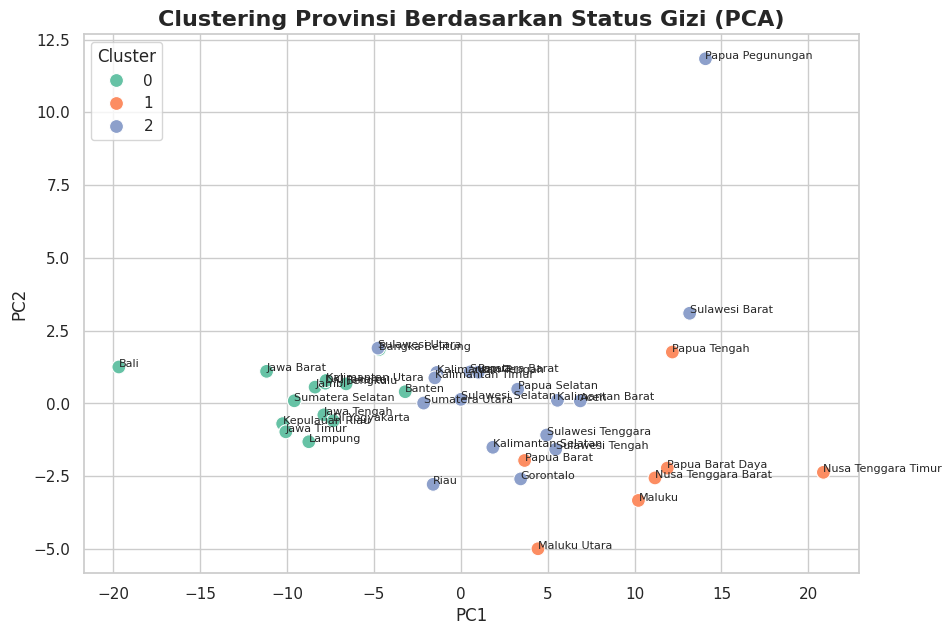

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Needed for clustering
from sklearn.cluster import KMeans # Needed for clustering

# 1. Clean df: Remove the summary row that contains NaN values for features
#    The row 'Kabupaten/Kota' has NaN for Stunting, Underweight, etc.
#    Use .dropna(subset=cols) for robustness in case other rows might also have NaNs
cols = ['Stunting','Underweight','Wasting','Severe Wasting','Overweight'] # Corrected 'Severe_Wasting' to 'Severe Wasting'
df_cleaned = df_select.dropna(subset=cols).copy() # Changed df to df_select

# 2. Ambil fitur dari cleaned DataFrame for PCA
X_pca_features = df_cleaned[cols]

# 3. Perform Scaling and Clustering (re-do to ensure 'Cluster' column is aligned and present)
scaler = StandardScaler()
X_scaled_for_pca_clustering = scaler.fit_transform(X_pca_features)

# Use the same number of clusters as before (3) if it was the user's intent
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto') # n_init='auto' to silence warning
df_cleaned['Cluster'] = kmeans.fit_predict(X_scaled_for_pca_clustering)

# 4. PCA jadi 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca_features)

# Assign PC1 and PC2 back to the *cleaned* DataFrame
df_cleaned['PC1'] = X_pca[:,0]
df_cleaned['PC2'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_cleaned, # Plot using the cleaned DataFrame with 'Cluster'
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    s=100
)

# 🔥 label provinsi
for i in range(len(df_cleaned)):
    plt.text(df_cleaned['PC1'].iloc[i], df_cleaned['PC2'].iloc[i], df_cleaned['Provinsi'].iloc[i], fontsize=8)

plt.title('Clustering Provinsi Berdasarkan Status Gizi (PCA)', fontsize=16, weight='bold')
plt.show()

Kolom provinsi di shapefile: PROVINSI


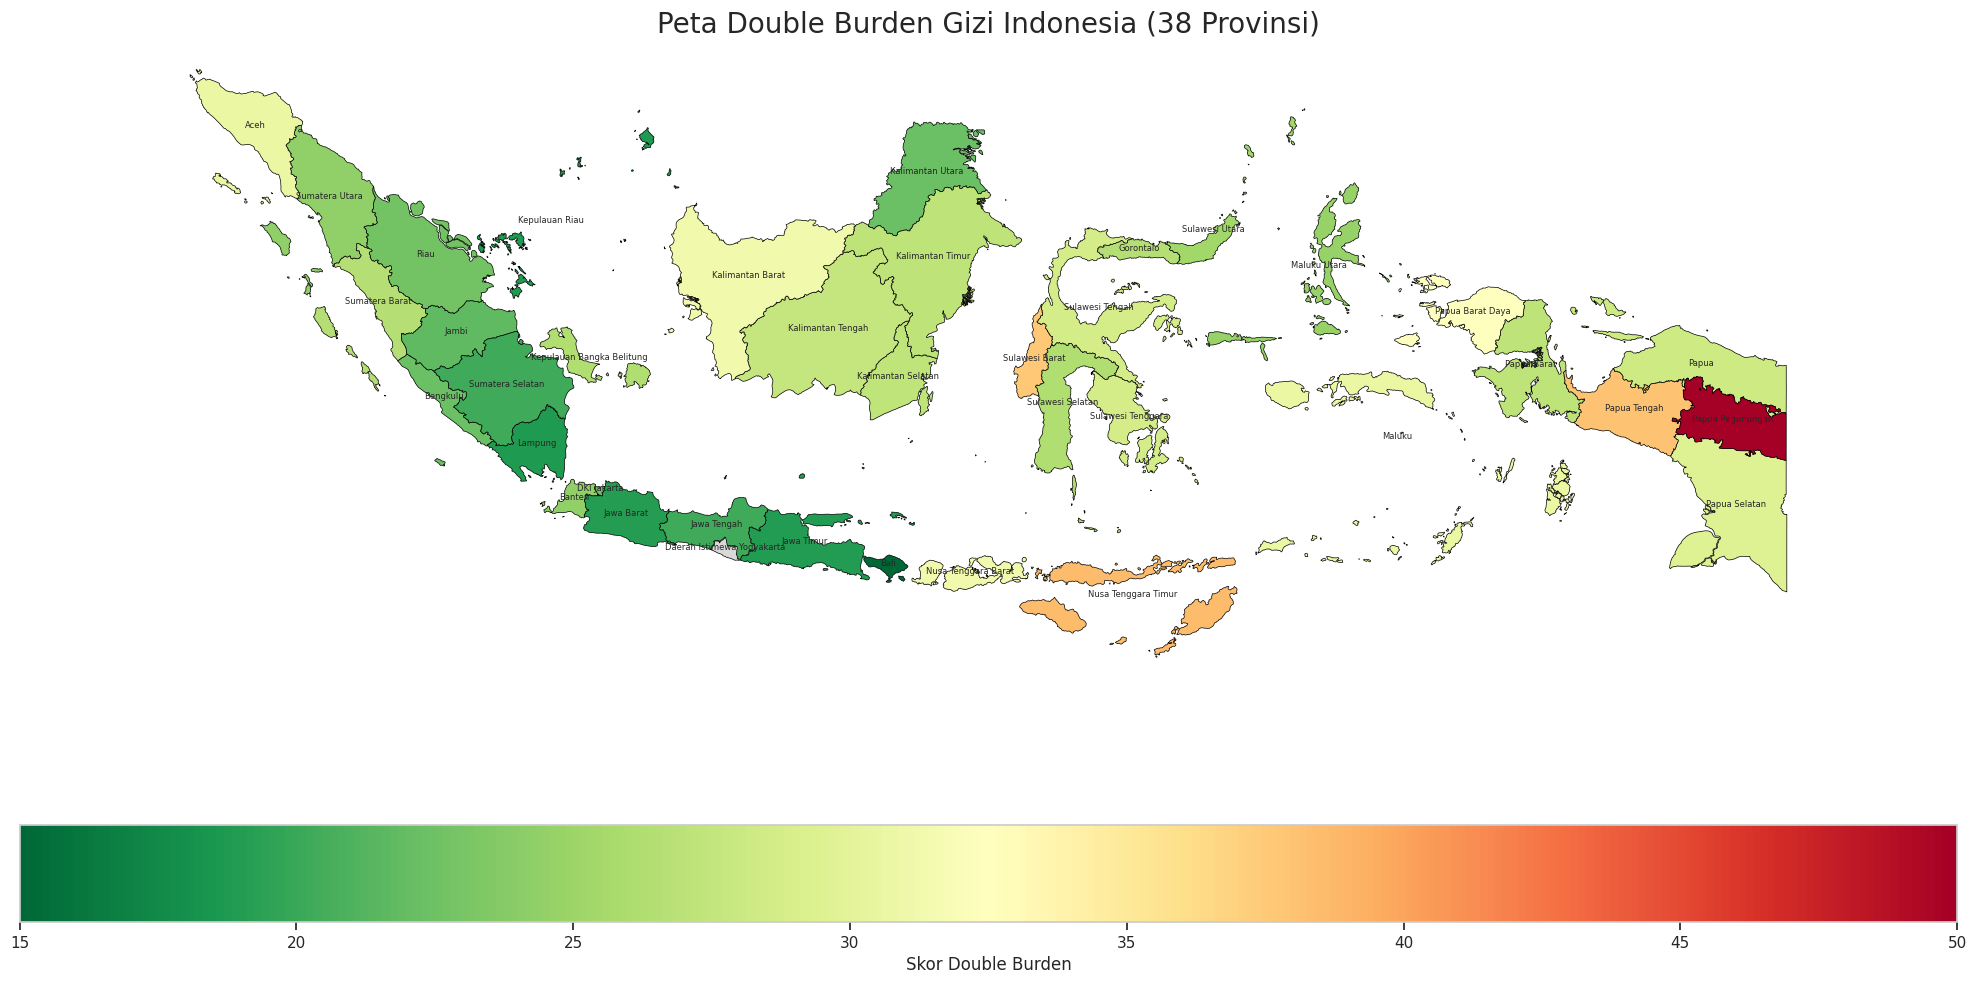

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import io

# =========================
# 1. DATA GIZI
# =========================
data = """Provinsi,Stunting,Overweight,Double_Burden_Score
Papua Pegunungan,40.0,10.3,50.3
Nusa Tenggara Timur,37.0,1.6,38.6
Papua Tengah,32.5,5.6,38.1
Sulawesi Barat,35.4,2.2,37.6
Papua Barat Daya,30.5,1.9,32.4
Kalimantan Barat,26.8,4.4,31.2
Nusa Tenggara Barat,29.8,1.4,31.2
Aceh,28.6,2.0,30.6
Maluku,28.4,2.2,30.6
Papua Selatan,25.8,3.8,29.6
Sulawesi Tenggara,26.1,2.7,28.8
Sulawesi Tengah,26.1,2.6,28.7
Papua,24.7,3.5,28.2
Kalimantan Tengah,22.1,5.5,27.6
Kalimantan Selatan,22.9,4.3,27.2
Kalimantan Timur,22.2,4.9,27.1
Papua Barat,24.6,2.5,27.1
Sumatera Barat,24.9,1.7,26.6
Gorontalo,23.8,2.7,26.5
Sulawesi Selatan,23.3,3.0,26.3
Kepulauan Bangka Belitung,20.1,6.2,26.3
Sulawesi Utara,20.8,4.5,25.3
Maluku Utara,23.2,1.5,24.7
Banten,21.1,3.3,24.4
Sumatera Utara,22.0,2.3,24.3
Riau,20.1,2.6,22.7
DKI Jakarta,17.3,5.3,22.6
Kalimantan Utara,17.6,4.7,22.3
Bengkulu,18.8,3.5,22.3
Jambi,17.1,4.6,21.7
DI Yogyakarta,17.4,3.1,20.5
Jawa Tengah,17.1,3.2,20.3
Sumatera Selatan,15.9,4.3,20.2
Jawa Barat,15.9,3.2,19.1
Jawa Timur,14.7,4.2,18.9
Lampung,15.9,2.9,18.8
Kepulauan Riau,15.0,3.7,18.7
Bali,8.7,6.4,15.1"""

df_gizi = pd.read_csv(io.StringIO(data))

# =========================
# 2. LOAD GEOJSON 38 PROVINSI
# =========================
url = "https://raw.githubusercontent.com/ardian28/GeoJson-Indonesia-38-Provinsi/main/Provinsi/38%20Provinsi%20Indonesia%20-%20Provinsi.json"
gdf = gpd.read_file(url)

# cari kolom nama provinsi
possible_cols = ['NAME_1', 'Provinsi', 'nama', 'NAME', 'PROVINSI', 'Propinsi']
name_col = next((c for c in possible_cols if c in gdf.columns), gdf.columns[0])

print("Kolom provinsi di shapefile:", name_col)

# =========================
# 3. NORMALISASI NAMA
# =========================
def normalize(x):
    return x.upper().strip()

df_gizi["prov_clean"] = df_gizi["Provinsi"].apply(normalize)
gdf["prov_clean"] = gdf[name_col].apply(normalize)

# =========================
# 4. MERGE DATA (INI KUNCI)
# =========================
gdf = gdf.merge(df_gizi[["prov_clean", "Double_Burden_Score"]],
                on="prov_clean",
                how="left")

# =========================
# 5. PLOT PETA
# =========================
fig, ax = plt.subplots(1, 1, figsize=(25, 12))

gdf.plot(column="Double_Burden_Score",
         ax=ax,
         cmap="RdYlGn_r",
         legend=True,
         edgecolor="black",
         linewidth=0.5,
         vmin=15, vmax=50,
         missing_kwds={"color": "#d9d9d9"},
         legend_kwds={"label": "Skor Double Burden", "orientation": "horizontal"})

# =========================
# 6. LABEL
# =========================
for _, row in gdf.iterrows():
    if row.geometry:
        ax.annotate(text=row[name_col],
                    xy=row.geometry.centroid.coords[0],
                    ha="center",
                    fontsize=6)

plt.title("Peta Double Burden Gizi Indonesia (38 Provinsi)", fontsize=20)
ax.axis("off")
plt.show()